<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/HMM/HMM_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install hmmlearn



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn import hmm
import matplotlib.pyplot as plt

Fetching data for QQQ...


/tmp/ipykernel_3256/3979357279.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed


Training 3-State HMM on QQQ daily log returns...



STATE CHARACTERISTICS FOR QQQ

State 0:
  Expected Daily Log Return (Mean): 0.001364
  Expected Percent Return (Mean): 0.1365%
  Daily Volatility (Std Dev):     0.007732
  Days spent in this state:       1890 (75.1%)

State 1:
  Expected Daily Log Return (Mean): -0.001311
  Expected Percent Return (Mean): -0.1310%
  Daily Volatility (Std Dev):     0.017403
  Days spent in this state:       625 (24.9%)

Transition Probability Matrix (in %):
  From State 0: 97.92% 2.08% 
  From State 1: 5.68% 94.32% 


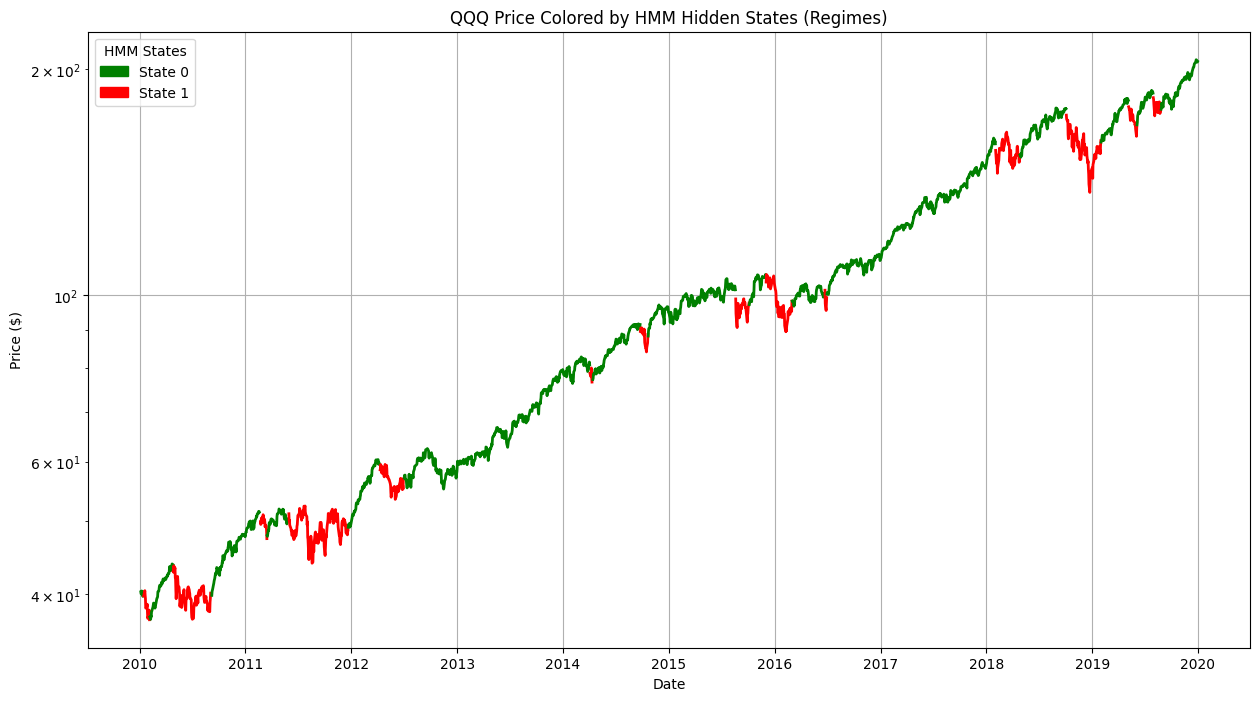

In [3]:
# ==========================================
# 1. CONFIGURATION & VARIABLE SETUP
# ==========================================
# Change this variable to "SPY", "IWM", or "QQQ"
TICKER = "QQQ"

START_DATE = "2010-01-01"
END_DATE = "2020-01-01"  # Adjust based on your preferred backtest window
N_STATES = 2

# ==========================================
# 2. DATA ACQUISITION & PREPROCESSING
# ==========================================
print(f"Fetching data for {TICKER}...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

# Calculate Daily Log Returns
# log(Rt) = log(Pt / Pt-1)
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

# Reshape data for hmmlearn (requires a 2D array: [samples, features])
X = df['Log_Return'].values.reshape(-1, 1)

# ==========================================
# 3. INITIALIZE AND FIT THE HMM
# ==========================================
# We use a Gaussian Emission HMM because log returns are continuous variables
model = hmm.GaussianHMM(
    n_components=N_STATES,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

print(f"Training 3-State HMM on {TICKER} daily log returns...")
model.fit(X)

# Predict the hidden states for each day
hidden_states = model.predict(X)
df['State'] = hidden_states

# ==========================================
# 4. INTERPRET THE STATES
# ==========================================
print("\n" + "="*40)
print(f"STATE CHARACTERISTICS FOR {TICKER}")
print("="*40)

state_means = model.means_.flatten()
state_vars = np.diag(model.covars_[:, 0]).flatten() if model.covariance_type == "diag" else model.covars_.flatten() # Assuming 1 feature

for i in range(N_STATES):
    state_data = df[df['State'] == i]
    # Convert log return mean to percent return mean
    percent_return_mean = (np.exp(state_means[i]) - 1) * 100
    print(f"\nState {i}:")
    print(f"  Expected Daily Log Return (Mean): {state_means[i]:.6f}")
    print(f"  Expected Percent Return (Mean): {percent_return_mean:.4f}%")
    print(f"  Daily Volatility (Std Dev):     {np.sqrt(state_vars[i]):.6f}")
    print(f"  Days spent in this state:       {len(state_data)} ({len(state_data)/len(df)*100:.1f}%)")

print("\nTransition Probability Matrix (in %):")
for i, row in enumerate(model.transmat_):
    print(f"  From State {i}: ", end="")
    for prob in row:
        print(f"{prob*100:.2f}% ", end="")
    print()

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(15, 8))
# Dynamically generate colors or provide enough for N_STATES
colors = ['green', 'red', 'blue', 'purple', 'orange', 'brown', 'pink', 'gray'] # Extended colors list
colors_map = {i: colors[i] for i in range(N_STATES)}

# Identify segments where the state is constant
# This creates a series that increments each time the state changes
state_segments = df['State'].diff().ne(0).cumsum()

# Plot each segment with its corresponding state color
for segment_id, segment_df in df.groupby(state_segments):
    state = segment_df['State'].iloc[0] # Get the state for this segment
    color = colors_map[state]
    plt.plot(segment_df.index, segment_df['Close'], color=color, linewidth=2) # Plot the segment as a line

plt.title(f"{TICKER} Price Colored by HMM Hidden States (Regimes)")
plt.xlabel("Date")
plt.ylabel("Price ($)")

# Create a custom legend as plotting in a loop creates multiple labels
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=colors_map[s], label=f'State {s}') for s in sorted(colors_map.keys())]
plt.legend(handles=legend_handles, title="HMM States")

plt.grid(True)
plt.yscale('log') # Useful for viewing multi-year index growth
plt.show()

## Applying the Trained HMM to New Data (Out-of-Sample Prediction)

Now, let's use the trained HMM to predict the hidden states for a period beyond our training data. We'll fetch new data and apply the model to it.

In [4]:
# Define the new date range for out-of-sample prediction
# 'END_DATE' from the original configuration is used as the START_DATE for this new period
PREDICTION_START_DATE = END_DATE
PREDICTION_END_DATE = pd.to_datetime('today').strftime('%Y-%m-%d')

print(f"Fetching new data for {TICKER} from {PREDICTION_START_DATE} to {PREDICTION_END_DATE}...")
df_new = yf.download(TICKER, start=PREDICTION_START_DATE, end=PREDICTION_END_DATE)

# Calculate Daily Log Returns for the new data
df_new['Log_Return'] = np.log(df_new['Close'] / df_new['Close'].shift(1))
df_new.dropna(inplace=True)

# Reshape data for hmmlearn
X_new = df_new['Log_Return'].values.reshape(-1, 1)

print(f"Predicting hidden states for {TICKER} on new data...")
hidden_states_new = model.predict(X_new)
df_new['State'] = hidden_states_new

display(df_new.head())

Fetching new data for QQQ from 2020-01-01 to 2026-06-13...


/tmp/ipykernel_3256/787473543.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_new = yf.download(TICKER, start=PREDICTION_START_DATE, end=PREDICTION_END_DATE)
[*********************100%***********************]  1 of 1 completed

Predicting hidden states for QQQ on new data...


Price,Close,High,Low,Open,Volume,Log_Return,State
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ,,
Date,,,,,,,
2020-01-03,206.409332,207.652538,205.541991,205.561270,27518900,-0.009202,0
2020-01-06,207.739288,207.768199,204.539749,204.790310,21655300,0.006423,0
2020-01-07,207.710419,208.298288,207.055097,207.816428,22139300,-0.000139,0
2020-01-08,209.271606,210.225694,207.353815,207.681476,26397300,0.007488,0
2020-01-09,211.044891,211.449652,209.811332,210.996702,23547000,0.008438,0


In [11]:
# --- Warm-up Data for Sequential Prediction ---
# Fetch some historical data prior to PREDICTION_START_DATE to "warm up" the HMM
WARM_UP_DAYS = 30 # Number of days prior to PREDICTION_START_DATE for warm-up
warm_up_start_date = (pd.to_datetime(PREDICTION_START_DATE) - pd.DateOffset(days=WARM_UP_DAYS)).strftime('%Y-%m-%d')

print(f"Fetching warm-up data for {TICKER} from {warm_up_start_date} to {PREDICTION_START_DATE}...")
warm_up_df = yf.download(TICKER, start=warm_up_start_date, end=PREDICTION_START_DATE)

# Calculate Daily Log Returns for warm-up data
warm_up_df['Log_Return'] = np.log(warm_up_df['Close'] / warm_up_df['Close'].shift(1))
warm_up_df.dropna(inplace=True)

X_warm_up = warm_up_df['Log_Return'].values.reshape(-1, 1)
print(f"Warm-up data fetched: {len(X_warm_up)} samples.")

Fetching warm-up data for QQQ from 2019-12-02 to 2020-01-01...


/tmp/ipykernel_3256/3659390954.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  warm_up_df = yf.download(TICKER, start=warm_up_start_date, end=PREDICTION_START_DATE)
[*********************100%***********************]  1 of 1 completed

Warm-up data fetched: 20 samples.


The `X_warm_up` will be used to initialize the first state of the sequential prediction, without adding any actual states to `df_new` from this warm-up period.

### Interpreting States for the New Data

Let's see how the market regimes (states) are distributed in this new period according to our trained HMM.

In [5]:
print("\n" + "="*40)
print(f"STATE CHARACTERISTICS FOR {TICKER} (NEW DATA)")
print("="*40)

for i in range(N_STATES):
    state_data_new = df_new[df_new['State'] == i]
    if not state_data_new.empty:
        # Convert log return mean to percent return mean (using the model's learned means)
        # Note: We use the *trained model's* means, not recalculating from new data's small sample
        percent_return_mean = (np.exp(model.means_.flatten()[i]) - 1) * 100
        print(f"\nState {i}:")
        print(f"  Expected Daily Log Return (Mean - from model): {model.means_.flatten()[i]:.6f}")
        print(f"  Expected Percent Return (Mean - from model): {percent_return_mean:.4f}%")
        print(f"  Daily Volatility (Std Dev - from model):     {np.sqrt(model.covars_.flatten()[i]):.6f}")
        print(f"  Days spent in this state (new data):       {len(state_data_new)} ({len(state_data_new)/len(df_new)*100:.1f}%)")
    else:
        print(f"\nState {i}: Not observed in new data.")


STATE CHARACTERISTICS FOR QQQ (NEW DATA)

State 0:
  Expected Daily Log Return (Mean - from model): 0.001364
  Expected Percent Return (Mean - from model): 0.1365%
  Daily Volatility (Std Dev - from model):     0.007732
  Days spent in this state (new data):       840 (51.9%)

State 1:
  Expected Daily Log Return (Mean - from model): -0.001311
  Expected Percent Return (Mean - from model): -0.1310%
  Daily Volatility (Std Dev - from model):     0.017403
  Days spent in this state (new data):       779 (48.1%)


### Visualization of New Data with Predicted States

Finally, let's visualize the price action of the new data, colored by the hidden states predicted by our HMM.

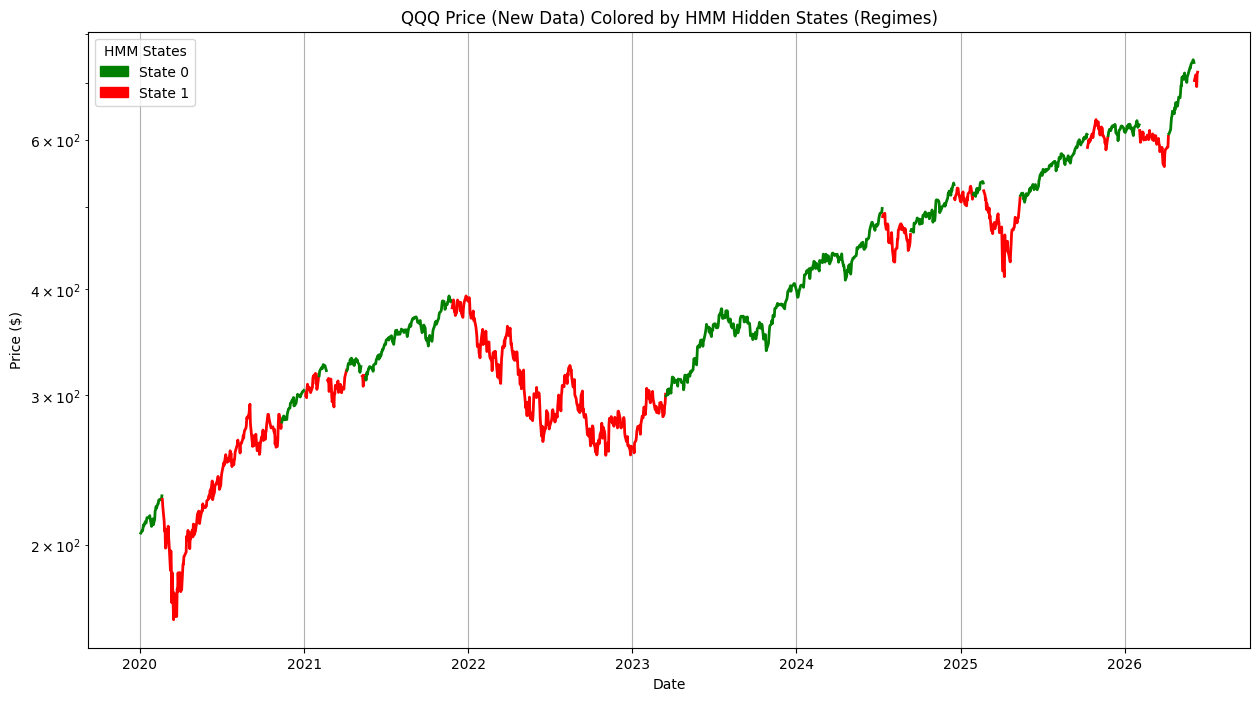

In [6]:
plt.figure(figsize=(15, 8))

# Reuse the colors_map created during the training phase
# colors_map = {i: colors[i] for i in range(N_STATES)} (already defined in previous cell)

# Identify segments where the state is constant for the new data
state_segments_new = df_new['State'].diff().ne(0).cumsum()

# Plot each segment with its corresponding state color
for segment_id, segment_df in df_new.groupby(state_segments_new):
    state = segment_df['State'].iloc[0] # Get the state for this segment
    color = colors_map[state]
    plt.plot(segment_df.index, segment_df['Close'], color=color, linewidth=2)

plt.title(f"{TICKER} Price (New Data) Colored by HMM Hidden States (Regimes)")
plt.xlabel("Date")
plt.ylabel("Price ($)")

# Create a custom legend
legend_handles = [mpatches.Patch(color=colors_map[s], label=f'State {s}') for s in sorted(colors_map.keys())]
plt.legend(handles=legend_handles, title="HMM States")

plt.grid(True)
plt.yscale('log')
plt.show()

## Sequential Prediction (Simulating Real-time, t-1 Basis)

To simulate a real-time, online prediction scenario, we've adjusted the approach so that the state for each day `t` is predicted based **only on the observations available up to day `t-1`**, without 'seeing' data from day `t` onwards. This is a more realistic simulation of making predictions in real-time.

Here's how it works:

*   **For the first day (Day 0):** The state is determined by the model's initial state probabilities (`model.startprob_`).
*   **For subsequent days (Day `t`):**
    1.  We consider all observations from the start of the prediction period up to day `t-1` (i.e., $O_0, \dots, O_{t-1}$).
    2.  The model calculates the posterior probabilities of being in each hidden state at time `t-1` given these observations ($P(H_{t-1} | O_0, \dots, O_{t-1})$).
    3.  These posterior probabilities are then projected one step forward using the model's transition matrix (`model.transmat_`) to estimate the probabilities of being in each state at time `t` ($P(H_t | O_0, \dots, O_{t-1})$).
    4.  The predicted state for day `t` is the one with the highest probability from this projection.

This method explicitly enforces the `t-1` dependency, making it a more stringent and realistic simulation of online prediction compared to using `model.predict()` over a growing historical window.

In [12]:
# This cell performs sequential state prediction (t-1 basis).
print("Performing sequential state prediction (state for day t based on data up to day t-1)...")

sequential_states = []

if len(X_new) > 0:
    # Initialize posterior probabilities for the start of the prediction period (PREDICTION_START_DATE)
    # If warm-up data exists, use it to get the posterior at the end of the warm-up period.
    if len(X_warm_up) > 0:
        # Get posterior probabilities after processing warm-up data
        # This provides P(H_warmup_end | O_warmup_start ... O_warmup_end)
        initial_posterior_for_prediction_period = model.predict_proba(X_warm_up)[-1]
    else:
        # If no warm-up data, use the model's initial state probabilities (P(H_0))
        initial_posterior_for_prediction_period = model.startprob_

    # First day of X_new (index 0): Predict H_0 based on the 'warmed-up' initial probabilities
    # Project these probabilities one step forward using the transition matrix to get P(H_0 | O_warmup)
    predicted_probs_for_day_0 = np.dot(initial_posterior_for_prediction_period, model.transmat_)
    state_for_day_0 = np.argmax(predicted_probs_for_day_0)
    sequential_states.append(state_for_day_0)

    # For subsequent days (index i from 1 to len(X_new) - 1)
    # Predict H_i based on observations O_0, ..., O_{i-1} of X_new
    for i in range(1, len(X_new)):
        # Observations from O_0 up to O_{i-1} from X_new
        observations_up_to_i_minus_1_of_X_new = X_new[:i]

        # Combine warm-up observations with X_new observations up to i-1
        # This creates the full observation sequence: O_warmup, O_0, ..., O_{i-1}
        full_observation_sequence = np.concatenate((X_warm_up, observations_up_to_i_minus_1_of_X_new))

        # Get posterior probabilities of states at time (i-1) of X_new
        # model.predict_proba(full_observation_sequence) returns probabilities for each observation in the slice.
        # We need the probabilities for the *last* observation (O_{i-1} of X_new), which is at index -1.
        posterior_probs_at_i_minus_1 = model.predict_proba(full_observation_sequence)[-1]

        # Project these probabilities one step forward using the transition matrix.
        # This gives P(H_i | O_warmup, O_0,...,O_{i-1})
        predicted_probs_for_state_i = np.dot(posterior_probs_at_i_minus_1, model.transmat_)

        # The predicted state for day 'i' is the one with the highest probability
        state_for_day_i = np.argmax(predicted_probs_for_state_i)
        sequential_states.append(state_for_day_i)

# Add the sequential states to the DataFrame, replacing the old 'Sequential_State' column
df_new['Sequential_State'] = sequential_states

print("Sequential prediction (t-1 basis) complete.")
display(df_new[['Close', 'Log_Return', 'State', 'Sequential_State']].head())

Performing sequential state prediction (state for day t based on data up to day t-1)...
Sequential prediction (t-1 basis) complete.


Price,Close,Log_Return,State,Sequential_State
Ticker,QQQ,,,
Date,,,,
2020-01-03,206.409332,-0.009202,0,0
2020-01-06,207.739288,0.006423,0,0
2020-01-07,207.710419,-0.000139,0,0
2020-01-08,209.271606,0.007488,0,0
2020-01-09,211.044891,0.008438,0,0


### Visualization of New Data with Sequential Predicted States

Now let's visualize the price action of the new data, colored by the *sequential* hidden states predicted by our HMM. Compare this to the previous batch prediction visualization to observe the differences.

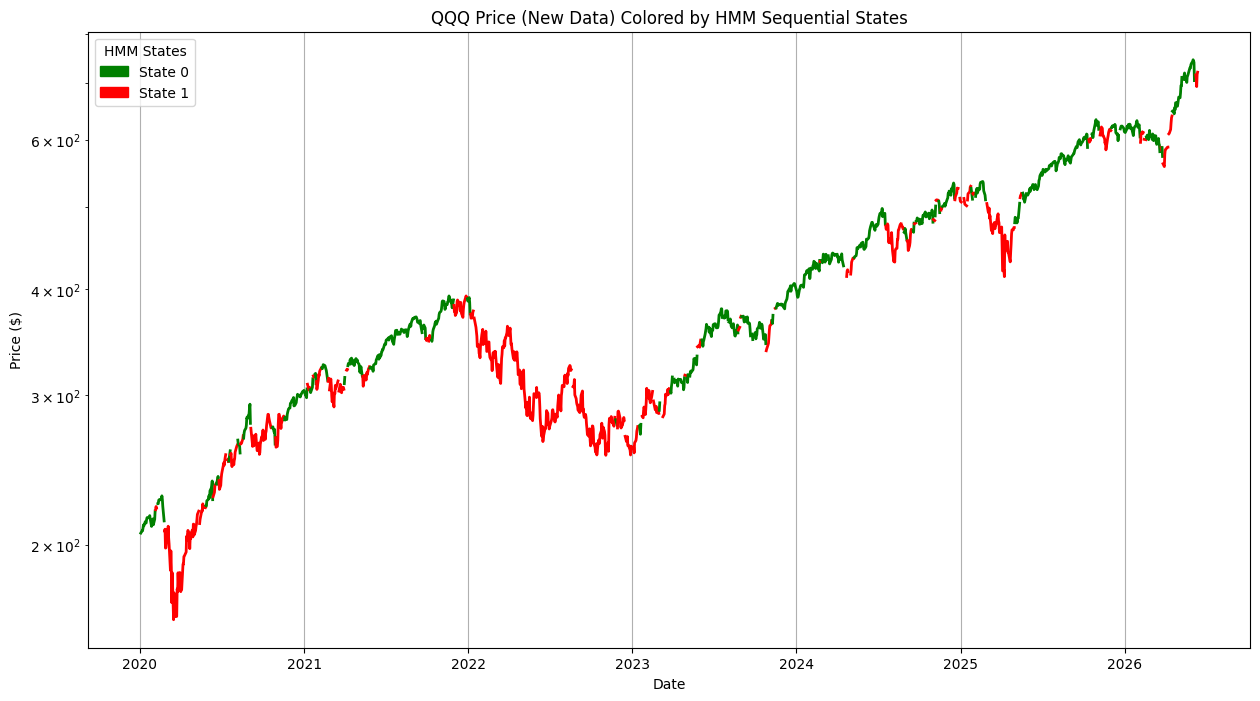

In [13]:
plt.figure(figsize=(15, 8))

# Identify segments where the sequential state is constant for the new data
state_segments_sequential = df_new['Sequential_State'].diff().ne(0).cumsum()

# Plot each segment with its corresponding state color
for segment_id, segment_df in df_new.groupby(state_segments_sequential):
    state = segment_df['Sequential_State'].iloc[0] # Get the state for this segment
    color = colors_map[state]
    plt.plot(segment_df.index, segment_df['Close'], color=color, linewidth=2)

plt.title(f"{TICKER} Price (New Data) Colored by HMM Sequential States")
plt.xlabel("Date")
plt.ylabel("Price ($)")

# Create a custom legend (reusing colors_map)
import matplotlib.patches as mpatches # Ensure mpatches is imported
legend_handles = [mpatches.Patch(color=colors_map[s], label=f'State {s}') for s in sorted(colors_map.keys())]
plt.legend(handles=legend_handles, title="HMM States")

plt.grid(True)
plt.yscale('log')
plt.show()